# **MLP Combine with vector Space:** 

### SUMMARY
Each word is mapped to a point in a continuous vector space via an embedding lookup.
Embeddings from the context are concatenated and passed through an MLP, which transforms these coordinates into logits.
Softmax normalizes the logits into a probability distribution over the vocabulary

IMPORTS:

In [1]:
import torch 
import random
import torch.nn.functional as F
import matplotlib.pyplot as plt

c:\Users\Yashraj Sharma\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\cuda\__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


GETTING FAMILIAR WITH DATA:

In [2]:
words=open('names.txt','r').read().splitlines()
print(words[:8])
len(words)

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


32033

INDEXING:

In [3]:
chars=sorted(list(set(''.join(words))))
stoi={s:i+1 for i,s in enumerate(chars)}
stoi['.']=0
itos={i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


BUILDING DATASET:

In [4]:
def build_dataset(words):
    block_size=3
    X,Y=[],[]
    for w in words:
        context=[0]*block_size
        for ch in w+'.':
            ix=stoi[ch]
            X.append(context)
            Y.append(ix)
            context=context[1:]+[ix]

    X=torch.tensor(X)
    Y=torch.tensor(Y)
    return X,Y


# Creating Training , Validation and Test sets
random.seed(42)
random.shuffle(words)

n1=int(len(words)*0.8)
n2=int(len(words)*0.9)
Xtr,Ytr=build_dataset(words[:n1])
Xdev,Ydev=build_dataset(words[n1:n2])
Xte,Yte=build_dataset(words[n2:])

print("Shape of X:",Xtr.shape) # Means there are 3 characters in the context in 32 training examples.
print("Data type of X:",Xtr.dtype)
print("Shape of Y:",Ytr.shape) # Means there is only 1 output character in 32 training examples.
print("Data type of Y:",Ytr.dtype)

Shape of X: torch.Size([182625, 3])
Data type of X: torch.int64
Shape of Y: torch.Size([182625])
Data type of Y: torch.int64


INPUT EMBEDDINGS:

In [5]:
### Generating the embeddings:
C= torch.randn((27,2)) # 27 is the number of characters in the vocabulary and 2 is the size of the embedding vector for each character menas 2 dimensions for each character. We can choose any number of dimensions for the embedding vector, but 2 is a good choice for visualization purposes.
emb = C[Xtr] # (32,3,2) # 32 training examples, 3 characters in the context, and 2 dimensions for each character.(batch, context, embedding)
# means a context window of 3 characters is being mapped to a 2-dimensional embedding vector for each character in the context. So, we have a total of 32 training examples, and each example consists of a context window of 3 characters, which is represented as a 2-dimensional embedding vector for each character in the context.
# so in this, each particular charater in context is being mapped to a 2-dimensional embedding vector, and we have a total of 32 training examples, where each example consists of a context window of 3 characters, and each character in the context is represented as a 2-dimensional embedding vector.
print(emb[1][2][0]) # this is the first dimension of the embedding vector for the third character in the context of the second training example becuase of 0-based indexing.

tensor(1.8180)


HIDDEN LAYER WITH ACTIVATION FUNCTION:

In [6]:
W1 = torch.randn((6,100)) # 6 is the number of input features (3 characters in the context * 2 dimensions for each character) and 100 is the number of neurons in the hidden layer.
b1 = torch.randn(100) # 100 is the number of neurons in the hidden layer.

# But There is a problem here, usually we to emb @ W1 + b1, but the shape of emb is (32,3,2) and the shape of W1 is (6,100), so we need to reshape emb to (32,6) before we can perform the matrix multiplication.
#emb_reshaped = torch.cat([emb[:,0,:],emb[:,1,:],emb[:,2,:]],dim=1) # this is the first, second and third character in the context for all 32 training examples, reshaped to (32,6)
# emb_reshaped = torch.cat(torch.unbind(emb,dim=1)) # this will give us a list of 3 tensors, each of shape (32,2), which is the first, second and third character in the context for all 32 training examples.
emb_reshaped = emb.view(emb.shape[0], -1) # this will reshape the emb tensor to (32,6) by concatenating the 3 characters in the context for all 32 training examples.
# Now we can perform the matrix multiplication and add the bias to get the output of the hidden layer. shape will be (32,6) @ (6,100) + (100,) = (32,100)
h= torch.tanh(emb_reshaped @ W1 + b1) # this will give us the output of the hidden layer, which is a tensor of shape (32,100), where 32 is the number of training examples and 100 is the number of neurons in the hidden layer. Each row in this tensor represents the output of the hidden layer for a particular training example.

OUTPUT LAYER:

In [7]:
w2= torch.randn((100,27)) # 100 is the number of neurons in the hidden layer and 27 is the number of characters in the vocabulary, which is also the number of output classes.
b2= torch.randn(27) # 27 is the number of characters in the vocabulary, which is also the number of output classes.

logits = h @ w2 + b2 # this will give us the logits for each of the 27 output classes for each of the 32 training examples. The shape of logits will be (32,27), where 32 is the number of training examples and 27 is the number of output classes.
count= logits.exp() # this will give us the unnormalized probabilities for each of the 27 output classes for each of the 32 training examples. The shape of count will be (32,27), where 32 is the number of training examples and 27 is the number of output classes.
prob= count / count.sum(dim=1, keepdim=True) # this will give us the normalized probabilities for each of the 27 output classes for each of the 32 training examples. The shape of prob will be (32,27), where 32 is the number of training examples and 27 is the number of output classes. Each row in this tensor represents a probability distribution over the 27 output classes for a particular training example.
prob[torch.arange(Xtr.shape[0]),Ytr] # this will give us the probabilities of the correct output class for each of the 32 training examples. The shape of this tensor will be (32,), where each element represents the probability of the correct output class for a particular training example. We can use these probabilities to compute the loss and perform backpropagation to update the weights and biases of the model during training.

tensor([2.8512e-07, 4.7387e-15, 1.1262e-10,  ..., 3.1292e-17, 3.7868e-09,
        4.0211e-17])

(LOSS CALCULATION)NEGATIVE LOGLIKELIHOOD:

In [8]:
loss=-prob[torch.arange(Xtr.shape[0]),Ytr].log().mean() # this will give us the average negative log-likelihood loss for the 32 training examples. The shape of this tensor will be a scalar, which represents the average loss for the batch of training examples. We can use this loss to perform backpropagation and update the weights and biases of the model during training.
loss

tensor(17.4540)

The above way of computing the loss is not very efficient because we are computing the probabilities for all the output classes, which is not necessary. We can directly compute the loss from the logits without computing the probabilities, which is more efficient and numerically stable.

We can use the cross-entropy loss function, which combines the softmax function and the negative log-likelihood loss into a single function. The cross-entropy loss can be computed as follows:

loss = torch.nn.functional.cross_entropy(logits, Y) # scalar

why this is better?

reason 1: It is more efficient because we are not computing the probabilities for all the output classes, which is not necessary. We only need the logits for the correct output class to compute the loss, and the cross-entropy loss function allows us to do that directly without computing the probabilities.

reason 2: It is more numerically stable because it avoids the potential issues of computing the probabilities, which can lead to very small values that can cause underflow when taking the logarithm. The cross-entropy loss function is designed to handle this issue and provides a more stable way to compute the loss directly from the logits.

### **CODE FLOW**

WEIGHTS AND BIAS:

In [9]:
G=torch.Generator().manual_seed(2147483647)
C= torch.randn((27,2), generator=G) 
W1 = torch.randn((6,100), generator=G) 
b1 = torch.randn(100, generator=G) 
W2 = torch.randn((100,27), generator=G) 
b2 = torch.randn(27, generator=G)
parameters = [C, W1, b1, W2, b2]

In [10]:
#Number of parameters in the model
total_params = sum(p.numel() for p in parameters)
print(f'Total number of parameters in the model: {total_params}')

Total number of parameters in the model: 3481


LEARNING RATE CALCULATION(TRICK): 

In [11]:
lre = torch.linspace(-3, 0, 1000)   # exponent from 10^-3 to 10^0
lri = 10**lre                      # actual learning rate

TRAINING BLOCK:

In [12]:
Lr_exp = []
Lr = []
Loss = []

for p in parameters:
    p.requires_grad = True

for i in range(200000):
    # Mini batch of 32 random examples from the training data
    # Mini-batch training speeds up optimization by trading exact gradients for frequent, efficient, and slightly noisy updates.
    ix=torch.randint(0,Xtr.shape[0],(32,)) # this will give us a tensor of shape (32,) containing random integers between 0 and 4, which we can use as indices to select a random batch of 32 training examples from the dataset. We can use these indices to index into the X and Y tensors to get the input and output for the selected batch of training examples.
    # Forward pass
    embeddings = C[Xtr[ix]] # (32,3,2)
    embeddings_reshaped = embeddings.view(embeddings.shape[0], -1) # (32,6)
    hpreact=embeddings_reshaped @ W1 + b1# (32,100)
    hidden_layer_output = torch.tanh(hpreact) # (32,100)
    logits = hidden_layer_output @ W2 + b2 # (32,27)
    loss=F.cross_entropy(logits, Ytr[ix]) # this will give us the average cross-entropy loss for the 32 training examples. The shape of this tensor will be a scalar, which represents the average loss for the batch of training examples. We can use this loss to perform backpropagation and update the weights and biases of the model during training

    # Backward pass
    for p in parameters:
        p.grad = None # Gradients are accumulated by default in PyTorch, so we need to set them to None before calling backward() to prevent accumulation of gradients from previous iterations.
    loss.backward()

    # Update parameters using gradient descent
    lr=0.1
    with torch.no_grad():
        for p in parameters:
            p += -lr * p.grad 

    # Track the learning rate and loss for visualization purposes
    # Lr.append(lr)
    # Lr.append(lri[i])
    # Lr_exp.append(lre[i])
    # Loss.append(loss.item())

TRAINING LOSS: 

In [13]:
# After training the model for 100 iterations, we can evaluate the final loss on the entire training dataset to see how well the model has learned to predict the next character based on the context of the previous characters.
random.seed(42)
embeddings = C[Xtr] # (32,3,2)
embeddings_reshaped = embeddings.view(embeddings.shape[0], -1) # (32,6)
hidden_layer_output = torch.tanh(embeddings_reshaped @ W1 + b1) # (32,100)
logits = hidden_layer_output @ W2 + b2 # (32,27)
loss=F.cross_entropy(logits, Ytr) # this will give us the average cross-entropy loss for the 32 training examples. The shape of this tensor will be a scalar, which represents the average loss for the batch of training examples. We can use this loss to perform backpropagation and update the weights and biases of the model during training
print("Original Training loss:",loss.item())

Original Training loss: 2.2935421466827393


DEVELOPMENT LOSS:

In [14]:
# After training the model for 100 iterations, we can evaluate the final loss on the entire training dataset to see how well the model has learned to predict the next character based on the context of the previous characters.
random.seed(42)
embeddings = C[Xdev] # (32,3,2)
embeddings_reshaped = embeddings.view(embeddings.shape[0], -1) # (32,6)
hidden_layer_output = torch.tanh(embeddings_reshaped @ W1 + b1) # (32,100)
logits = hidden_layer_output @ W2 + b2 # (32,27)
loss=F.cross_entropy(logits, Ydev) # this will give us the average cross-entropy loss for the 32 training examples. The shape of this tensor will be a scalar, which represents the average loss for the batch of training examples. We can use this loss to perform backpropagation and update the weights and biases of the model during training
print("Original Development loss:",loss.item())

Original Development loss: 2.2988171577453613


VISUALISATION:

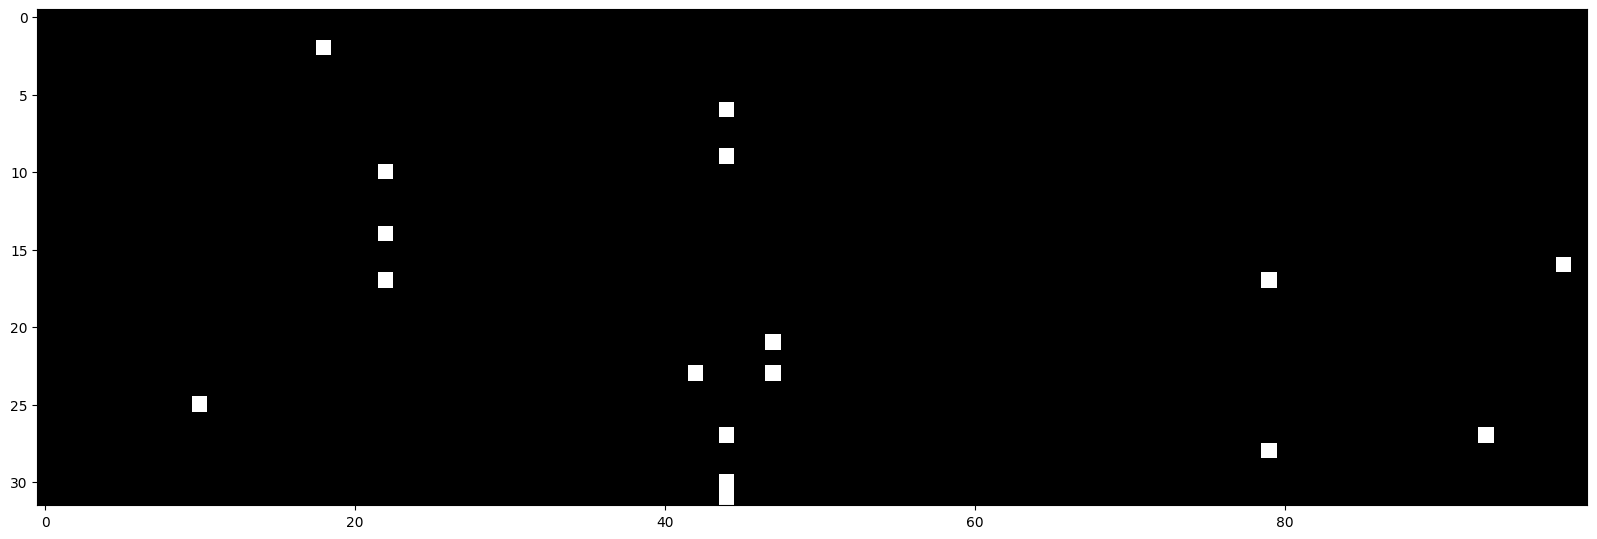

In [71]:
plt.figure(figsize=(20,8))
plt.imshow(hidden_layer_output.abs() > 0.98, cmap='gray', interpolation='nearest')
#there are many black values which shows that many values close to 1 or -1 and passing them through tanh activation will vanish the gradient.

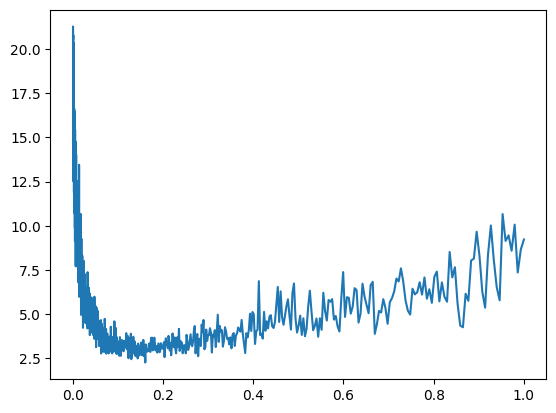

In [62]:
plt.plot(Lr, Loss)

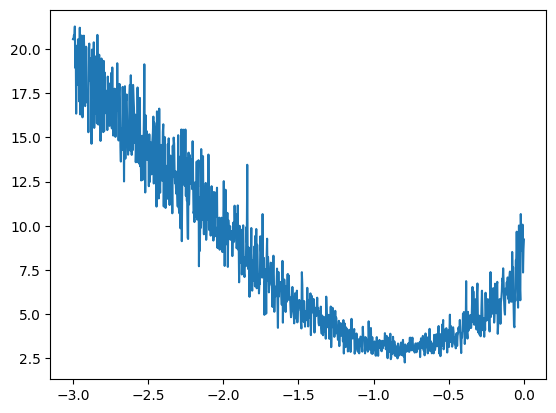

In [61]:
plt.plot(Lr_exp, Loss)

# If our training and validation loss turns out to be close it means our network parameters are too small and we need bigger NN with larger parameters

# OPTIMIZATION 1:

### Bigger Network:

In [42]:
G=torch.Generator().manual_seed(2147483647)
C= torch.randn((27,2), generator=G) 
W1 = torch.randn((6,300), generator=G)
b1 = torch.randn(300, generator=G)
W2 = torch.randn((300,27), generator=G)
b2 = torch.randn(27, generator=G)
parameters = [C, W1, b1, W2, b2]

In [43]:
#Number of parameters in the model
total_params = sum(p.numel() for p in parameters)
print(f'Total number of parameters in the model: {total_params}')

Total number of parameters in the model: 10281


In [44]:
for p in parameters:
    p.requires_grad = True

for i in range(200000):
    # Mini batch of 32 random examples from the training data
    # Mini-batch training speeds up optimization by trading exact gradients for frequent, efficient, and slightly noisy updates.
    ix=torch.randint(0,Xtr.shape[0],(32,)) # this will give us a tensor of shape (32,) containing random integers between 0 and 4, which we can use as indices to select a random batch of 32 training examples from the dataset. We can use these indices to index into the X and Y tensors to get the input and output for the selected batch of training examples.
    # Forward pass
    embeddings = C[Xtr[ix]] # (32,3,2)
    embeddings_reshaped = embeddings.view(embeddings.shape[0], -1) # (32,6)
    hpreact=embeddings_reshaped @ W1 + b1# (32,100)
    hidden_layer_output = torch.tanh(hpreact) # (32,100)
    logits = hidden_layer_output @ W2 + b2 # (32,27)
    loss=F.cross_entropy(logits, Ytr[ix]) # this will give us the average cross-entropy loss for the 32 training examples. The shape of this tensor will be a scalar, which represents the average loss for the batch of training examples. We can use this loss to perform backpropagation and update the weights and biases of the model during training

    # Backward pass
    for p in parameters:
        p.grad = None # Gradients are accumulated by default in PyTorch, so we need to set them to None before calling backward() to prevent accumulation of gradients from previous iterations.
    loss.backward()

    # Update parameters using gradient descent
    lr=0.1
    with torch.no_grad():
        for p in parameters:
            p += -lr * p.grad 

In [45]:
# After training the model for 30000 iterations, we can evaluate the final loss on the entire training dataset to see how well the model has learned to predict the next character based on the context of the previous characters.
random.seed(42)
embeddings = C[Xtr] # (32,3,2)
embeddings_reshaped = embeddings.view(embeddings.shape[0], -1) # (32,6)
hidden_layer_output = torch.tanh(embeddings_reshaped @ W1 + b1) # (32,300)
logits = hidden_layer_output @ W2 + b2 # (32,27)
loss=F.cross_entropy(logits, Ytr) # this will give us the average cross-entropy loss for the 32 training examples. The shape of this tensor will be a scalar, which represents the average loss for the batch of training examples. We can use this loss to perform backpropagation and update the weights and biases of the model during training
print(loss.item())

2.3274359703063965


In [46]:
# After training the model for 100 iterations, we can evaluate the final loss on the entire training dataset to see how well the model has learned to predict the next character based on the context of the previous characters.
random.seed(42)
embeddings = C[Xdev] # (32,3,2)
embeddings_reshaped = embeddings.view(embeddings.shape[0], -1) # (32,6)
hidden_layer_output = torch.tanh(embeddings_reshaped @ W1 + b1) # (32,100)
logits = hidden_layer_output @ W2 + b2 # (32,27)
loss=F.cross_entropy(logits, Ydev) # this will give us the average cross-entropy loss for the 32 training examples. The shape of this tensor will be a scalar, which represents the average loss for the batch of training examples. We can use this loss to perform backpropagation and update the weights and biases of the model during training
print(loss.item())

2.3389434814453125


# OPTIMIZATION 2 and 3:

### Making A Bigger Dimension LookUp table and Initializing the Weights and Bias according to Kaiming formula (std=gain/sqrt(fan_mode)):

In [47]:
G=torch.Generator().manual_seed(2147483647)
C= torch.randn((27,10), generator=G) 
W1 = torch.randn((30,200), generator=G) *0.03
b1 = torch.randn(200, generator=G)    * 0.01
W2 = torch.randn((200,27), generator=G) * 0.01
b2 = torch.randn(27, generator=G)   *0.01
parameters = [C, W1, b1, W2, b2]

In [48]:
# Number of parameters in the model
total_params = sum(p.numel() for p in parameters)
print(f'Total number of parameters in the model: {total_params}')

Total number of parameters in the model: 11897


In [49]:
for p in parameters:
    p.requires_grad = True

for i in range(200000):
    # Mini batch of 32 random examples from the training data
    # Mini-batch training speeds up optimization by trading exact gradients for frequent, efficient, and slightly noisy updates.
    ix=torch.randint(0,Xtr.shape[0],(32,)) # this will give us a tensor of shape (32,) containing random integers between 0 and 4, which we can use as indices to select a random batch of 32 training examples from the dataset. We can use these indices to index into the X and Y tensors to get the input and output for the selected batch of training examples.
    # Forward pass
    embeddings = C[Xtr[ix]] # (32,3,2)
    embeddings_reshaped = embeddings.view(embeddings.shape[0], -1) # (32,6)
    hidden_layer_output = torch.tanh(embeddings_reshaped @ W1 + b1) # (32,100)
    logits = hidden_layer_output @ W2 + b2 # (32,27)
    loss=F.cross_entropy(logits, Ytr[ix]) # this will give us the average cross-entropy loss for the 32 training examples. The shape of this tensor will be a scalar, which represents the average loss for the batch of training examples. We can use this loss to perform backpropagation and update the weights and biases of the model during training

    # Backward pass
    for p in parameters:
        p.grad = None # Gradients are accumulated by default in PyTorch, so we need to set them to None before calling backward() to prevent accumulation of gradients from previous iterations.
    loss.backward()

    # Update parameters using gradient descent
    lr=0.1 if i < 100000 else 0.01
    with torch.no_grad():
        for p in parameters:
            p += -lr * p.grad

In [50]:
# After training the model for 100 iterations, we can evaluate the final loss on the entire training dataset to see how well the model has learned to predict the next character based on the context of the previous characters.
random.seed(42)
embeddings = C[Xtr] # (32,3,2)
embeddings_reshaped = embeddings.view(embeddings.shape[0], -1) # (32,6)
hidden_layer_output = torch.tanh(embeddings_reshaped @ W1 + b1) # (32,100)
logits = hidden_layer_output @ W2 + b2 # (32,27)
loss=F.cross_entropy(logits, Ytr) # this will give us the average cross-entropy loss for the 32 training examples. The shape of this tensor will be a scalar, which represents the average loss for the batch of training examples. We can use this loss to perform backpropagation and update the weights and biases of the model during training
print(loss.item())

2.099210023880005


In [51]:
# After training the model for 100 iterations, we can evaluate the final loss on the entire training dataset to see how well the model has learned to predict the next character based on the context of the previous characters.
random.seed(42)
embeddings = C[Xdev] # (32,3,2)
embeddings_reshaped = embeddings.view(embeddings.shape[0], -1) # (32,6)
hidden_layer_output = torch.tanh(embeddings_reshaped @ W1 + b1) # (32,100)
logits = hidden_layer_output @ W2 + b2 # (32,27)
loss=F.cross_entropy(logits, Ydev) # this will give us the average cross-entropy loss for the 32 training examples. The shape of this tensor will be a scalar, which represents the average loss for the batch of training examples. We can use this loss to perform backpropagation and update the weights and biases of the model during training
print(loss.item())

2.1369383335113525


# OPTIMIZATION 4:

Even in shallow nets, activation scale can drift and cause:

Saturation (tanh/sigmoid)

Dead neurons (ReLU)

Poor gradient scaling

### BATCH NORMALIZATION:

Training without BN:
Each layer must constantly adapt to the shifting distribution of the previous layer.

Training with BN:
Each layer sees approximately standardized input every step.

During training, the distribution of activations at each layer changes due to updates in lower layers. This drift can push nonlinearities into unstable regimes. Batch Normalization stabilizes these distributions by enforcing zero mean and unit variance per batch, improving gradient flow and optimization conditioning

We need bngain and bnbias because:
before BN: z=Wx+b
after BN: z=z-mean/std

so it losses its functionality , so to restore it we use that.

When you train with a batch (say 32 examples), BatchNorm:

Looks at all 32 examples

Calculates their average (mean)

Calculates how spread out they are (std)

Uses those numbers to normalize activation

But every batch is slightly different.

So the mean and std change a little each time.

That means:

-> The same example can produce slightly different activations depending on which batch it’s in.

That small variation = jitter.

In [ ]:
G=torch.Generator().manual_seed(2147483647)
C= torch.randn((27,10), generator=G) 
W1 = torch.randn((30,200), generator=G) *0.03
b1 = torch.randn(200, generator=G)    * 0.01
W2 = torch.randn((200,27), generator=G) * 0.01
b2 = torch.randn(27, generator=G)   *0.01
bngain=torch.ones((1,200))
bnbias=torch.zeros((1,200))
bnmean_running=torch.zeros((1,200))
bnstd_running=torch.ones((1,200))
parameters = [C, W1, b1, W2, b2, bngain, bnbias]

In [ ]:
for p in parameters:
    p.requires_grad = True

for i in range(200000):
    
    # Mini batch of 32 random examples from the training data
    # Mini-batch training speeds up optimization by trading exact gradients for frequent, efficient, and slightly noisy updates.
    ix=torch.randint(0,Xtr.shape[0],(32,)) # this will give us a tensor of shape (32,) containing random integers between 0 and 4, which we can use as indices to select a random batch of 32 training examples from the dataset. We can use these indices to index into the X and Y tensors to get the input and output for the selected batch of training examples.

    # Do the Forward pass:
    embeddings = C[Xtr[ix]] # (32,3,2)
    embeddings_reshaped = embeddings.view(embeddings.shape[0], -1) # (32,6)
    hpreact=embeddings_reshaped @ W1 # + b1# (32,100) #pre activation no need of bias here because we will add it after batch normalization

    ### Adding a batch Normalization:
    bnmean=hpreact.mean(dim=0, keepdim=True) # this will give us the mean of the pre-activation values for each neuron in the hidden layer across the batch of training examples. The shape of this tensor will be (1,100), where 1 is the batch dimension and 100 is the number of neurons in the hidden layer.
    bnstd=hpreact.std(dim=0, keepdim=True) # this will give us the standard deviation of the pre-activation values for each neuron in the hidden layer across the batch of training examples. The shape of this tensor will be (1,100), where 1 is the batch dimension and 100 is the number of neurons in the hidden layer.
    hpreact=bngain*(hpreact - bnmean) / (bnstd + 1e-5)+bnbias # this will normalize the pre-activation values of the hidden layer by subtracting the mean and dividing by the standard deviation for each neuron in the hidden layer. This can help to stabilize the training process and improve the convergence of the model. 
    with torch.no_grad():
        bnmean_running=0.9*bnmean_running + 0.1*bnmean
        bnstd_running=0.9*bnstd_running + 0.1*bnstd
    #we use this running mean and std to normalize the pre-activation values during inference when we don't have a batch of training examples to compute the mean and std from. During inference, we will use the running mean and std to normalize the pre-activation values of the hidden layer, which can help to improve the performance of the model on unseen data.

    # non-linearity
    hidden_layer_output = torch.tanh(hpreact) # (32,100)
    logits = hidden_layer_output @ W2 + b2 # (32,27)

    #Calculate the loss:
    loss=F.cross_entropy(logits, Ytr[ix]) # this will give us the average cross-entropy loss for the 32 training examples. The shape of this tensor will be a scalar, which represents the average loss for the batch of training examples. We can use this loss to perform backpropagation and update the weights and biases of the model during training

    # Backward pass
    for p in parameters:
        #optimizer zero grad
        p.grad = None # Gradients are accumulated by default in PyTorch, so we need to set them to None before calling backward() to prevent accumulation of gradients from previous iterations.
    #loss backward
    loss.backward()

    # Update parameters using gradient descent
    #optimizer step
    lr=0.1 if i < 100000 else 0.01
    with torch.no_grad():
        for p in parameters:
            p += -lr * p.grad

In [54]:
# After training the model for 100 iterations, we can evaluate the final loss on the entire training dataset to see how well the model has learned to predict the next character based on the context of the previous characters.
random.seed(42)
embeddings = C[Xtr] # (32,3,2)
embeddings_reshaped = embeddings.view(embeddings.shape[0], -1) # (32,6)
hpreact=embeddings_reshaped @ W1 + b1# (32,100) #pre activation
hpreact=bngain*(hpreact - hpreact.mean(dim=0, keepdim=True)) / (hpreact.std(dim=0, keepdim=True))+bnbias # batch normalization
hidden_layer_output = torch.tanh(hpreact) # (32,100)
logits = hidden_layer_output @ W2 + b2 # (32,27)
loss=F.cross_entropy(logits, Ytr) # this will give us the average cross-entropy loss for the 32 training examples. The shape of this tensor will be a scalar, which represents the average loss for the batch of training examples. We can use this loss to perform backpropagation and update the weights and biases of the model during training
print(loss.item())

2.0580813884735107


In [55]:
# After training the model for 100 iterations, we can evaluate the final loss on the entire training dataset to see how well the model has learned to predict the next character based on the context of the previous characters.
random.seed(42)
embeddings = C[Xdev] # (32,3,2)
embeddings_reshaped = embeddings.view(embeddings.shape[0], -1) # (32,6)
hpreact=embeddings_reshaped @ W1 + b1# (32,100) #pre activation
hpreact=bngain*(hpreact - hpreact.mean(dim=0, keepdim=True)) / (hpreact.std(dim=0, keepdim=True))+bnbias # batch normalization
hidden_layer_output = torch.tanh(hpreact) # (32,100)
logits = hidden_layer_output @ W2 + b2 # (32,27)
loss=F.cross_entropy(logits, Ydev) # this will give us the average cross-entropy loss for the 32 training examples. The shape of this tensor will be a scalar, which represents the average loss for the batch of training examples. We can use this loss to perform backpropagation and update the weights and biases of the model during training
print(loss.item())

2.103177547454834


# PROOFS OF INITIAL PROBLEMS FOR WHICH OPTIMIZATIONS IS MADE:

1.weights and bias initialization of hidden and output layer is random so it gives high loss in the starting but is should around:

In [20]:
# for example:
logits_=torch.tensor([1.0,1.0,1.0,1.0]) # if the tensor contains very large values, the softmax function will assign a probability of 1 to the largest value and a probability of 0 to all other values, which can lead to numerical instability and loss of information. In this case, the softmax function will assign a probability of 1 to the first value (99.0) and a probability of 0 to the other values (12.0, 1.0, 1.0), which can lead to a loss of information about the relative differences between the values in the tensor.
probs=F.softmax(logits_,dim=0)
loss=-probs[0].log().mean()
print("loss:",loss)
print("logits:",logits_)
print("probs:",probs)

loss: tensor(1.3863)
logits: tensor([1., 1., 1., 1.])
probs: tensor([0.2500, 0.2500, 0.2500, 0.2500])


So we will work for better initialization of weights and bias to take care of Tanh activations as well as logits near to zero

2.The distribution of initial weights as they as the Tanh Activation function:

(array([  2.,   1.,   0.,   2.,   0.,   3.,   2.,   3.,   9.,  13.,  12.,
         17.,  21.,  38.,  51.,  62.,  78.,  87., 124., 150., 133., 165.,
        170., 200., 230., 213., 185., 195., 147., 174., 125., 125., 119.,
         71.,  62.,  56.,  40.,  19.,  28.,  21.,  16.,  10.,   3.,   8.,
          2.,   6.,   1.,   0.,   0.,   1.]),
 array([-3.0689795 , -2.94742199, -2.82586448, -2.70430696, -2.58274945,
        -2.46119194, -2.33963443, -2.21807692, -2.0965194 , -1.97496189,
        -1.85340438, -1.73184687, -1.61028935, -1.48873184, -1.36717433,
        -1.24561682, -1.12405931, -1.00250179, -0.88094428, -0.75938677,
        -0.63782926, -0.51627174, -0.39471423, -0.27315672, -0.15159921,
        -0.03004169,  0.09151582,  0.21307333,  0.33463084,  0.45618835,
         0.57774587,  0.69930338,  0.82086089,  0.9424184 ,  1.06397592,
         1.18553343,  1.30709094,  1.42864845,  1.55020597,  1.67176348,
         1.79332099,  1.9148785 ,  2.03643601,  2.15799353,  2.27955104,
 

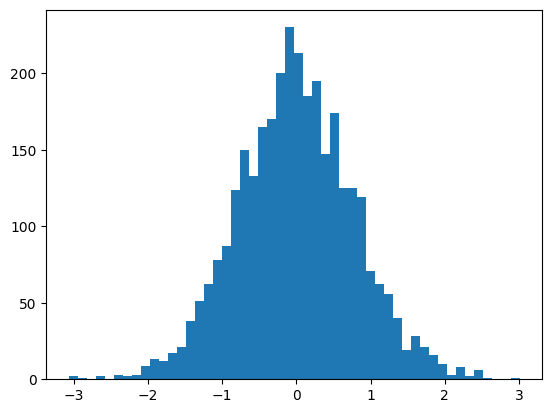

In [68]:
plt.hist(hpreact.view(-1).tolist(), bins=50)

(array([33., 37., 55., 65., 61., 71., 63., 79., 64., 77., 74., 65., 56.,
        74., 56., 71., 70., 56., 63., 65., 70., 77., 83., 69., 78., 60.,
        70., 70., 48., 76., 51., 78., 78., 58., 45., 70., 70., 74., 55.,
        72., 65., 66., 75., 70., 57., 62., 56., 50., 55., 37.]),
 array([-9.95690644e-01, -9.55873996e-01, -9.16057348e-01, -8.76240700e-01,
        -8.36424053e-01, -7.96607405e-01, -7.56790757e-01, -7.16974109e-01,
        -6.77157462e-01, -6.37340814e-01, -5.97524166e-01, -5.57707518e-01,
        -5.17890871e-01, -4.78074223e-01, -4.38257575e-01, -3.98440927e-01,
        -3.58624279e-01, -3.18807632e-01, -2.78990984e-01, -2.39174336e-01,
        -1.99357688e-01, -1.59541041e-01, -1.19724393e-01, -7.99077451e-02,
        -4.00910974e-02, -2.74449587e-04,  3.95421982e-02,  7.93588459e-02,
         1.19175494e-01,  1.58992141e-01,  1.98808789e-01,  2.38625437e-01,
         2.78442085e-01,  3.18258733e-01,  3.58075380e-01,  3.97892028e-01,
         4.37708676e-01,  4.7752

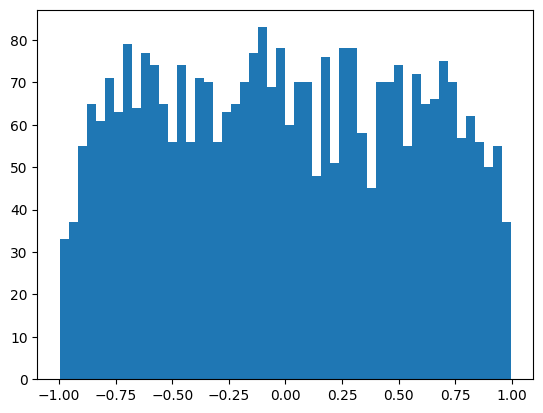

In [69]:
plt.hist(hidden_layer_output.view(-1).tolist(), bins=50)
# the distribution in hidden layer is very non uniform as many values are as high as 372 and negative also we in the initial iteration the tanh activation function is not able to squash the values in the hidden layer to a range between -1 and 1, which can lead to a non-uniform distribution of values in the hidden layer. This can make it difficult for the model to learn and can lead to a high loss during training.

So here we see most of the neurons are squashed as 1 and -1 , this is a problem because in Back Propagation the derivative of tanh is 1-t**2 *out.grad so if its -1 or 1 the gradient will turn to be xero and can cause vanishing gradient problem. 

# TO TAKE CARE OF BOTH PROBLEM ABOVE:

In [ ]:
# # We will multiply the W2 and b2 by 0.01 to make the logits smaller, which will make the probability distribution more uniform and lead to a lower loss.
# # Because we want logits to be near 0, which will make the probability distribution more uniform and lead to a lower loss.
# W1_= torch.randn((6,100), generator=G) * 0.3 ## Taking care of intial weight and bias initialization to make the logits smaller, which will make the probability distribution more uniform and lead to a lower loss.
# b1_= torch.randn(100, generator=G) * 0.01
# h_= torch.tanh(emb_reshaped @ W1_ + b1_) # this will give us the output of the hidden layer, which is a tensor of shape (32,100), where 32 is the number of training examples and 100 is the number of neurons in the hidden layer. Each row in this tensor represents the output of the hidden layer for a particular training example.
# W2_= torch.randn((100,27), generator=G) * 0.01
# b2_= torch.randn(27, generator=G) * 0.01


# logits_ini= h_ @ W2_ + b2_ # this will give us the logits for each of the 27 output classes for each of the 32 training examples. The shape of logits will be (32,27), where 32 is the number of training examples and 27 is the number of output classes.
# probs = F.softmax(logits_ini, dim=1) # this will give us the normalized probabilities for each output class for each training example. The shape of probs will be (32,27).
# loss=-probs[torch.arange(Xtr.shape[0]),Ytr].log().mean() # this will give us the average negative log-likelihood loss for the 32 training examples. The shape of this tensor will be a scalar, which represents the average loss for the batch of training examples. We can use this loss to perform backpropagation and update the weights and biases of the model during training.
# print("logits:",logits_ini[0])
# print("probs:",probs[0])
# print("Initial loss:",loss)

### this is very helful in compresiong the logits and probabilities before and after scaling the W2 and b2 by 0.01, which will help us understand how the scaling affects the logits, probabilities, and loss.

# BUT HOW DO WE COME UP WITH THESE 0.01 OR ANY SCALE:

tensor(-0.0096) tensor(1.0148)
tensor(0.0112) tensor(1.6996)


(array([1.32634152e-05, 0.00000000e+00, 3.97902455e-05, 9.28439062e-05,
        1.06107321e-04, 1.85687812e-04, 3.84639040e-04, 8.48858571e-04,
        1.06107321e-03, 1.98951228e-03, 3.26280013e-03, 4.85440996e-03,
        8.05089301e-03, 1.24543469e-02, 1.85157276e-02, 2.99222646e-02,
        4.28806213e-02, 6.18075147e-02, 8.49919645e-02, 1.16306888e-01,
        1.53112865e-01, 1.84759373e-01, 2.20225746e-01, 2.41831849e-01,
        2.54445357e-01, 2.42256278e-01, 2.23170224e-01, 1.90276954e-01,
        1.53643401e-01, 1.19914537e-01, 8.90505695e-02, 6.27890075e-02,
        4.33846310e-02, 3.07578598e-02, 2.05185033e-02, 1.30777274e-02,
        8.44879547e-03, 5.22578558e-03, 3.27606355e-03, 2.13540984e-03,
        1.15391712e-03, 6.63170759e-04, 3.44848795e-04, 1.98951228e-04,
        6.63170759e-05, 1.19370737e-04, 0.00000000e+00, 2.65268304e-05,
        2.65268304e-05, 1.32634152e-05]),
 array([-9.24217129, -8.86519447, -8.48821766, -8.11124084, -7.73426403,
        -7.35728722, 

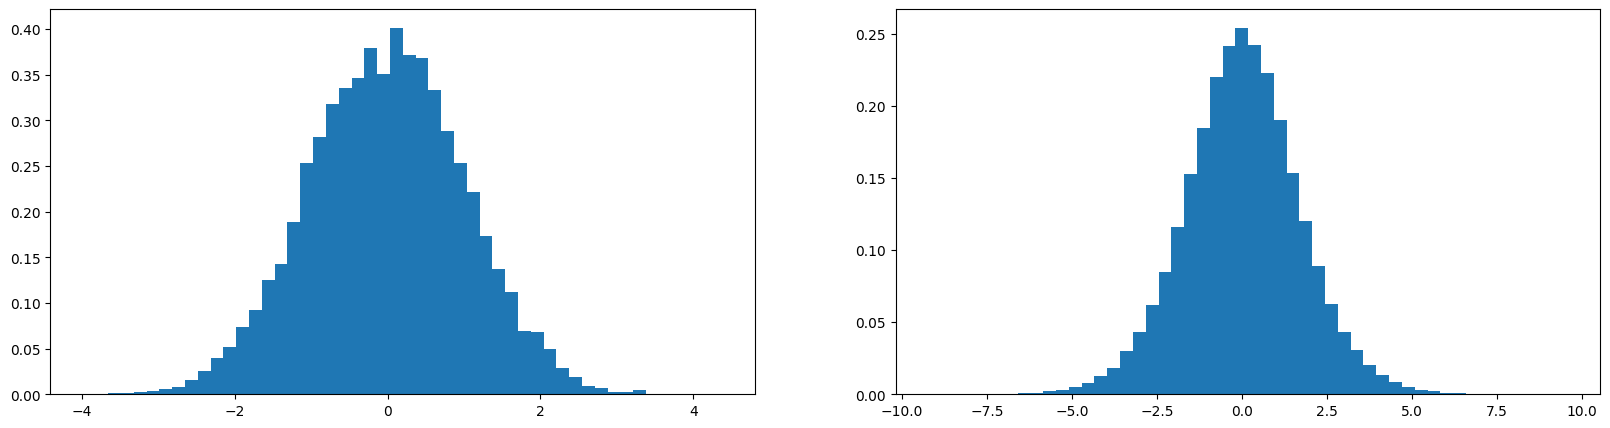

In [ ]:
x=torch.randn(1000,10)
w=torch.randn(10,200) * (5/3)/ (10**0.5) # this is the standard deviation of the weights for the hidden layer, which is calculated as 5/3 divided by the square root of the number of input features (10 in this case). This scaling helps to ensure that the standard deviation of the output of each layer is approximately 1, which can help with training stability and convergence.
h=x@w
print(x.mean(),x.std())
print(h.mean(),h.std()) ### So how we make the std uniform?????
##########################################################################
####(THUMB RULE in linear) The standard deviation of the output of each layer is approximately 1/sqrt(n), where n is the number of input features to the layer. By dividing the weights by sqrt(n), we can ensure that the standard deviation of the output of each layer is approximately 1, which can help with training stability and convergence.
#idea is to divide the weights by the square root of the number of input features to make the standard deviation of the output of each layer more uniform, which can help with training stability and convergence. This is known as Xavier initialization or Glorot initialization, and it is a common technique used in deep learning to initialize the weights of neural networks.
##########################################################################
#MODERN WAY OF INITIALIZATION
#std=gain/sqrt(fan_mode) 
plt.figure(figsize=(20,5))
plt.subplot(121)
plt.hist(x.view(-1).tolist(), bins=50,density=True)
plt.subplot(122)
plt.hist(h.view(-1).tolist(), bins=50, density=True)

In [ ]:
# torch.nn.init.kaiming_normal(w, mode='fan_in', nonlinearity='relu') # this will initialize the weights of a layer using Kaiming normal initialization, which is a method of initializing the weights of a neural network layer that is designed to work well with ReLU activation functions. The mode parameter specifies whether to use fan_in or fan_out initialization, and the nonlinearity parameter specifies the type of activation function used in the layer. In this case, we are using fan_in initialization and ReLU activation function. This initialization method can help with training stability and convergence by ensuring that the activations in the hidden layer have a more uniform distribution and preventing vanishing or exploding gradients during training.
#std=gain/sqrt(fan_mode) where gain is a scaling factor that depends on the nonlinearity used in the layer, and fan_in is the number of input features to the layer. By using Kaiming normal initialization, we can ensure that the standard deviation of the output of each layer is approximately 1, which can help with training stability and convergence when using ReLU activation functions.
##BUT WFY WE NEED GAIN??
# Because in activation functions we are basically squashing the values in the hidden layer to a range between 0 and infinity for ReLU activation function, which can lead to a non-uniform distribution of values in the hidden layer. The gain parameter is used to scale the weights of the layer to ensure that the standard deviation of the output of each layer is approximately 1, which can help with training stability and convergence when using ReLU activation functions. 

# Backward stability → gradient magnitude behavior
# Forward stability → activation distribution behavior
# Yes, mode="fan_in" vs mode="fan_out" is about which signal you want to preserve variance for:
# fan_in → preserve forward activation variance
# fan_out → preserve backward gradient variance

# LOSS LOG:

In [ ]:
# ORIGINAL:
# TRAINING LOSS:2.2935421466827393
# DEVLOPEMENT LOSS:2.2988171577453613

# OPTIMIZATION 1 (MORE HIDDEN NEURON):
# TRAINING LOSS:2.3274359703063965
# DEVLOPEMENT LOSS:2.3389434814453125

# OPTIMIZATION 2 (BIGGER LOOKUP TABLE) AND OPTIMIZATION 3 (BETTER INITIALIZATION-KAIMING):
# TRAINING LOSS:2.099210023880005
# DEVLOPEMENT LOSS:2.1369383335113525

# OPTIMIZATION 4 (BATCH NORMALIZATION):
# TRAINING LOSS:2.0580813884735107
# DEVLOPMENT LOSS:2.103177547454834